# Explore here

In [5]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

# Crear la ruta si no existe (tuve que hacerlo porque me daba error al intentar guardar el archivo en una carpeta que no existía)
path = "data/raw"
if not os.path.exists(path):
    os.makedirs(path)
df.to_csv("data/raw/medical_insurance_cost.csv", index=False)

# Cargar el dataset
url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"
df = pd.read_csv(url)

# Guardar en la carpeta de la plantilla como se ve en Captura de pantalla 2026-05-06 171256.jpg
df.to_csv("data/raw/medical_insurance_cost.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


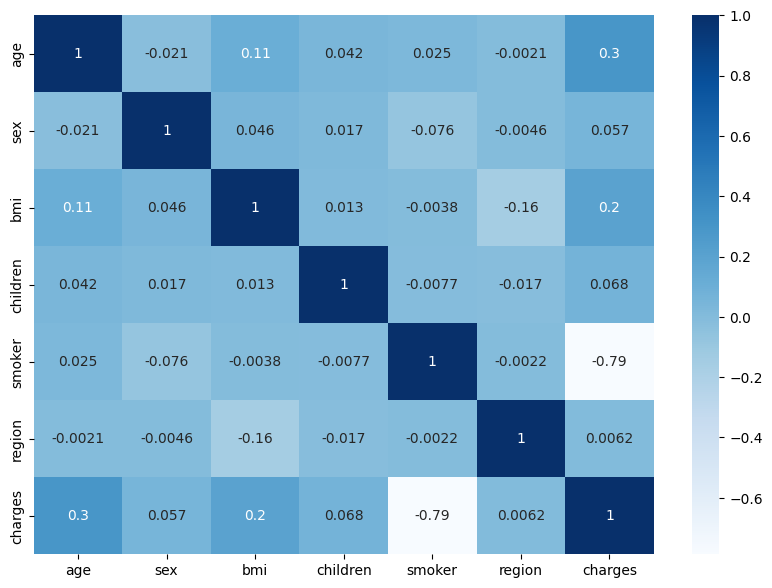

In [7]:
# 1. Información básica
print(df.info())

# 2. Convertir categóricas a numéricas (Factorize o One-Hot Encoding)
df['sex'] = pd.factorize(df['sex'])[0]
df['smoker'] = pd.factorize(df['smoker'])[0]
df['region'] = pd.factorize(df['region'])[0]

# 3. Análisis de correlación (Para ver qué variables afectan más al coste)
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

# 4. División Train y Test
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

El análisis de correlación muestra que el tabaquismo es el predictor más crítico para el coste del seguro, seguido por la edad. Variables como la región y el sexo muestran una influencia mínima, lo que nos permite centrarnos en las características fisiológicas más relevantes.

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluación inicial
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 33635210.43117841
R2 Score: 0.7833463107364538


In [10]:
# note que el R2 Score es un poco bajo, lo que indica que el modelo no está capturando bien la variabilidad de los datos. Esto sugiere que podríamos necesitar un modelo más complejo o realizar un mejor preprocesamiento de los datos para mejorar el rendimiento.
# así que aplicaré la Transformación Polinómica

from sklearn.preprocessing import PolynomialFeatures

# se crean variables de grado 2 (cuadráticas)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# se entrenan tiendo en cuenta los nuevos datos "curvos"
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

y_pred_poly = model_poly.predict(X_poly_test)
print(f"R2 Score con Polinomios: {r2_score(y_test, y_pred_poly)}")

R2 Score con Polinomios: 0.8677566718537746


Aqui se ve una mejora significativa en el R2 Score, lo que indica que el modelo polinómico está capturando mejor la variabilidad de los datos y proporcionando mejores predicciones.

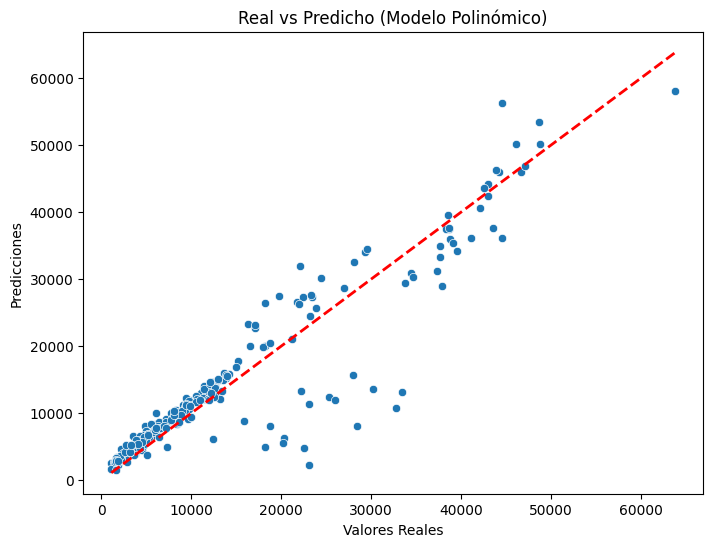

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (Modelo Polinómico)')
plt.show()

In [14]:
import os
import pickle  # <--- Te faltaba esta línea

# Crear la carpeta si no existe
if not os.path.exists("../models"):
    os.makedirs("../models")

# Guardar el modelo
pickle.dump(model_poly, open("../models/final_model.sav", "wb"))